In [1]:
import numpy as np
import pandas as pd
import scipy.signal as signal
import scipy.stats as stats
import matplotlib.pyplot as plt

# ==========================================
# 🔧 MASTER CONFIGURATION
# ==========================================
# 1. File & Device Settings
FILENAME = '../Python_tools/example12.csv'
FS = 400.0                   

# 2. ✂️ DATA SELECTION (NEW!)
# Set the range of samples you want to process.
# Use this to cut out the "garbage" at the start or end.
SAMPLE_START = 11000          # Skip first 1000 samples (2.5s settling time)
SAMPLE_END   = 14000         # Process up to sample 1000. Set to None for "Until End"

# 3. Thresholds (Validity Check)
THRESHOLD_RED = 180500
THRESHOLD_IR  = 115250

# 4. Filter Settings
KERNEL_SIZE = 1              # Spike Removal (Odd Number)
NORM_METHOD = "MINMAX"       # "ZSCORE" (Rec.) or "MINMAX"
LP_CUTOFF = 6.0             # Low Pass Frequency
LP_ORDER = 4                 # Filter Order

# ==========================================
# 🛠️ HELPER FUNCTIONS
# ==========================================
def apply_normalization(data, method="ZSCORE"):
    if len(data) == 0: return data
    if method == "MINMAX":
        return (data - np.min(data)) / (np.max(data) - np.min(data))
    elif method == "ZSCORE":
        return (data - np.mean(data)) / np.std(data)
    return data

print("✅ Configuration Loaded. Range Selected: ", SAMPLE_START, "to", SAMPLE_END)

✅ Configuration Loaded. Range Selected:  11000 to 14000


✅ Processing Range: 3000 samples.


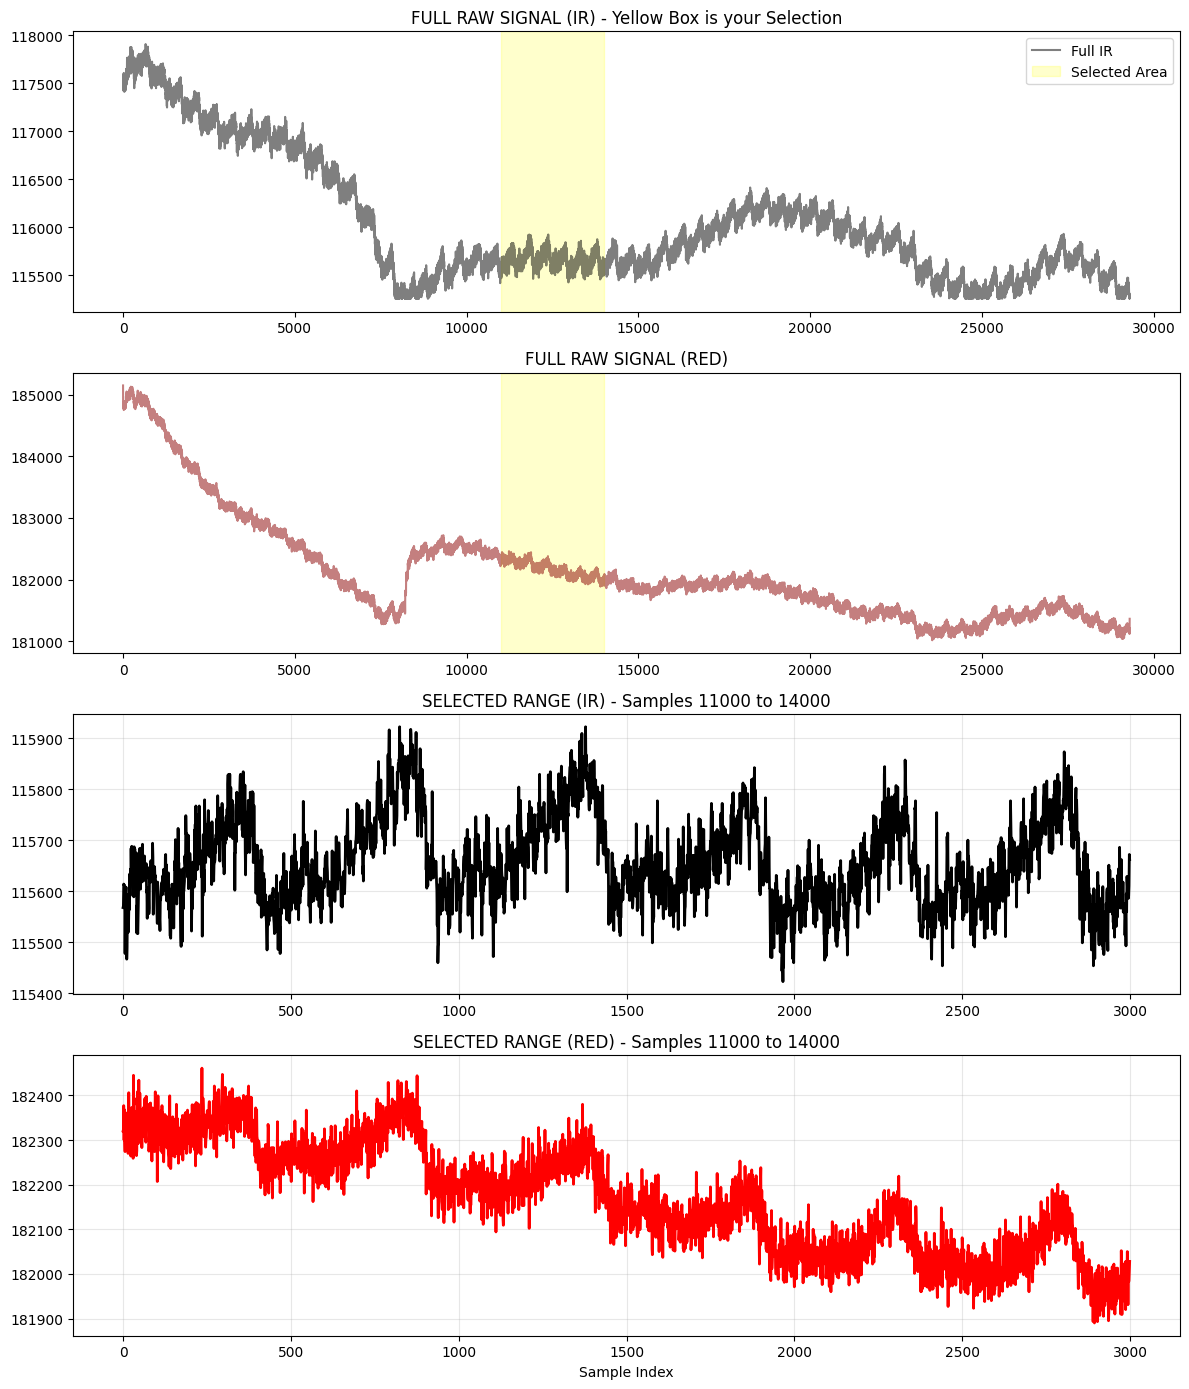

In [2]:
# ==========================================
# ⚙️ STEP 2: LOAD, SELECT & PLOT RAW
# ==========================================
# 1. Load CSV
df = pd.read_csv(FILENAME)
df.columns = df.columns.str.strip().str.upper()
rename_map = {'RED_VALUE': 'RED', 'IR_VALUE': 'IR', 'RED VALUE': 'RED', 'IR VALUE': 'IR'}
df = df.rename(columns=rename_map)

# 2. Apply Thresholds (Validity Check)
mask = (df['RED'] > THRESHOLD_RED) & (df['IR'] > THRESHOLD_IR)
full_clean_df = df[mask].copy()

# 3. ✂️ APPLY SELECTION (Slicing)
# We create a new DataFrame 'selected_df' that contains ONLY your range
if SAMPLE_END is None:
    selected_df = full_clean_df.iloc[SAMPLE_START:].copy()
else:
    selected_df = full_clean_df.iloc[SAMPLE_START:SAMPLE_END].copy()

# Safety Check
if len(selected_df) < 50:
    print(f"❌ CRITICAL ERROR: Selected range is too short ({len(selected_df)} samples)!")
else:
    print(f"✅ Processing Range: {len(selected_df)} samples.")

    # --- PLOTTING ---
    fig, axes = plt.subplots(4, 1, figsize=(12, 14))

    # Plot 1: FULL Data (IR)
    axes[0].plot(full_clean_df['IR'].values, color='black', alpha=0.5, label='Full IR')
    axes[0].axvspan(SAMPLE_START, SAMPLE_END if SAMPLE_END else len(full_clean_df), color='yellow', alpha=0.2, label='Selected Area')
    axes[0].set_title('FULL RAW SIGNAL (IR) - Yellow Box is your Selection')
    axes[0].legend()

    # Plot 2: FULL Data (RED)
    axes[1].plot(full_clean_df['RED'].values, color='darkred', alpha=0.5, label='Full RED')
    axes[1].axvspan(SAMPLE_START, SAMPLE_END if SAMPLE_END else len(full_clean_df), color='yellow', alpha=0.2)
    axes[1].set_title('FULL RAW SIGNAL (RED)')
    
    # Plot 3: SELECTED Data (IR)
    axes[2].plot(selected_df['IR'].values, color='black', linewidth=2, label='Selected IR')
    axes[2].set_title(f'SELECTED RANGE (IR) - Samples {SAMPLE_START} to {SAMPLE_END}')
    axes[2].grid(True, alpha=0.3)

    # Plot 4: SELECTED Data (RED)
    axes[3].plot(selected_df['RED'].values, color='red', linewidth=2, label='Selected RED')
    axes[3].set_title(f'SELECTED RANGE (RED) - Samples {SAMPLE_START} to {SAMPLE_END}')
    axes[3].grid(True, alpha=0.3)
    axes[3].set_xlabel('Sample Index')

    plt.tight_layout()
    plt.show()

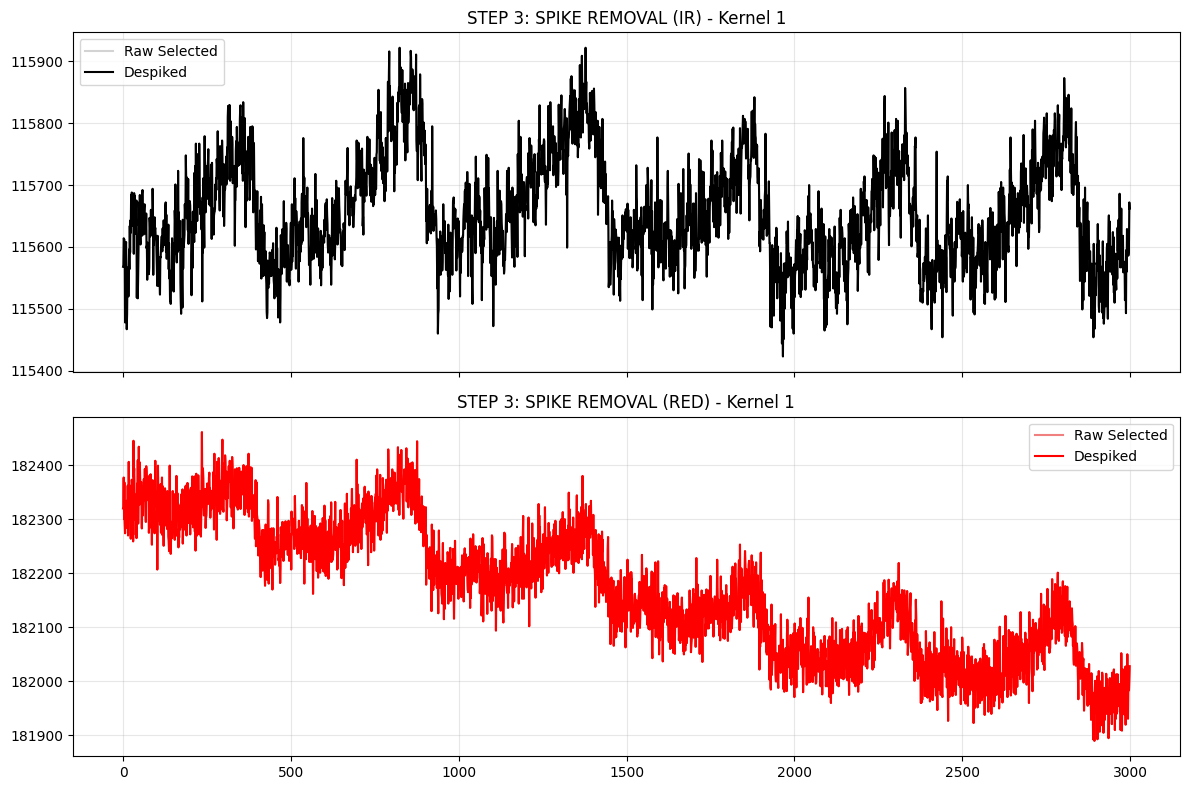

In [3]:
# ==========================================
# ⚙️ STEP 3: SPIKE REMOVAL
# ==========================================
# Apply Median Filter to the SELECTED data
ir_despiked  = signal.medfilt(selected_df['IR'].values, kernel_size=KERNEL_SIZE)
red_despiked = signal.medfilt(selected_df['RED'].values, kernel_size=KERNEL_SIZE)

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.plot(selected_df['IR'].values, color='lightgray', label='Raw Selected')
ax1.plot(ir_despiked, color='black', linewidth=1.5, label='Despiked')
ax1.set_title(f'STEP 3: SPIKE REMOVAL (IR) - Kernel {KERNEL_SIZE}')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(selected_df['RED'].values, color='lightcoral', label='Raw Selected')
ax2.plot(red_despiked, color='red', linewidth=1.5, label='Despiked')
ax2.set_title(f'STEP 3: SPIKE REMOVAL (RED) - Kernel {KERNEL_SIZE}')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

ℹ️  Filter Correction applied:
    Target Cutoff: 6.0 Hz (-3dB)
    Design Cutoff: 6.70 Hz (Shifted to compensate for double-pass)


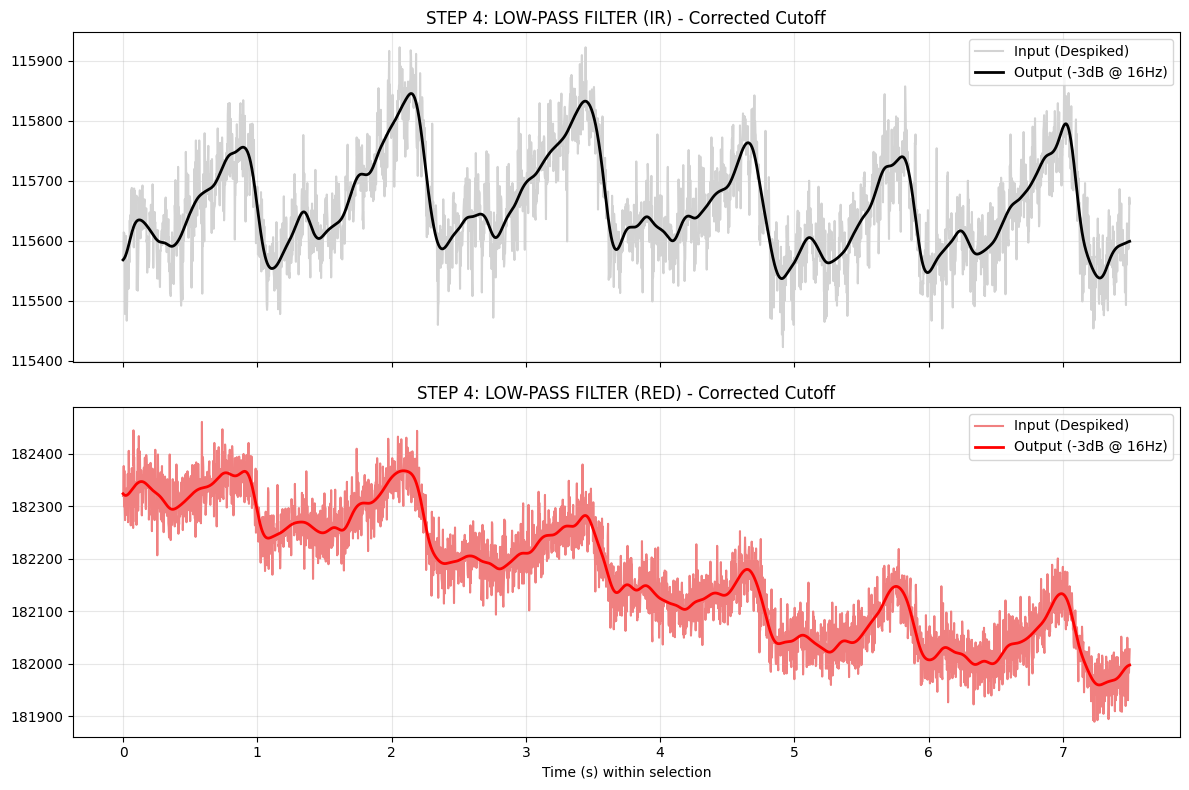

In [4]:
# ==========================================
# ⚙️ STEP 4: LOW-PASS FILTER (Updated: Exact -3dB Correction)
# ==========================================
# 1. Calculate Correction Factor for Zero-Phase Filter
# Why? sosfiltfilt runs twice, which doubles the attenuation (-3dB becomes -6dB).
# We adjust the cutoff so the FINAL result is exactly -3dB at LP_CUTOFF.
# Formula: C = (sqrt(2) - 1)^(1/2N)
correction_factor = (np.sqrt(2) - 1) ** (1 / (2 * LP_ORDER))
corrected_cutoff = LP_CUTOFF / correction_factor

print(f"ℹ️  Filter Correction applied:")
print(f"    Target Cutoff: {LP_CUTOFF} Hz (-3dB)")
print(f"    Design Cutoff: {corrected_cutoff:.2f} Hz (Shifted to compensate for double-pass)")

# 2. Design Filter with CORRECTED Cutoff
nyquist = 0.5 * FS
sos = signal.butter(LP_ORDER, corrected_cutoff / nyquist, btype='low', output='sos')

# 3. Apply Filter to DESPIKED data
# (Input comes from Step 3)
red_filtered = signal.sosfiltfilt(sos, red_despiked)
ir_filtered  = signal.sosfiltfilt(sos, ir_despiked)

# 4. Plot Results
t_select = np.arange(len(red_filtered)) / FS

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# IR Channel
ax1.plot(t_select, ir_despiked, color='lightgray', label='Input (Despiked)')
ax1.plot(t_select, ir_filtered, color='black', linewidth=2, label='Output (-3dB @ 16Hz)')
ax1.set_title(f'STEP 4: LOW-PASS FILTER (IR) - Corrected Cutoff')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# RED Channel
ax2.plot(t_select, red_despiked, color='lightcoral', label='Input (Despiked)')
ax2.plot(t_select, red_filtered, color='red', linewidth=2, label='Output (-3dB @ 16Hz)')
ax2.set_title(f'STEP 4: LOW-PASS FILTER (RED) - Corrected Cutoff')
ax2.set_xlabel('Time (s) within selection')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

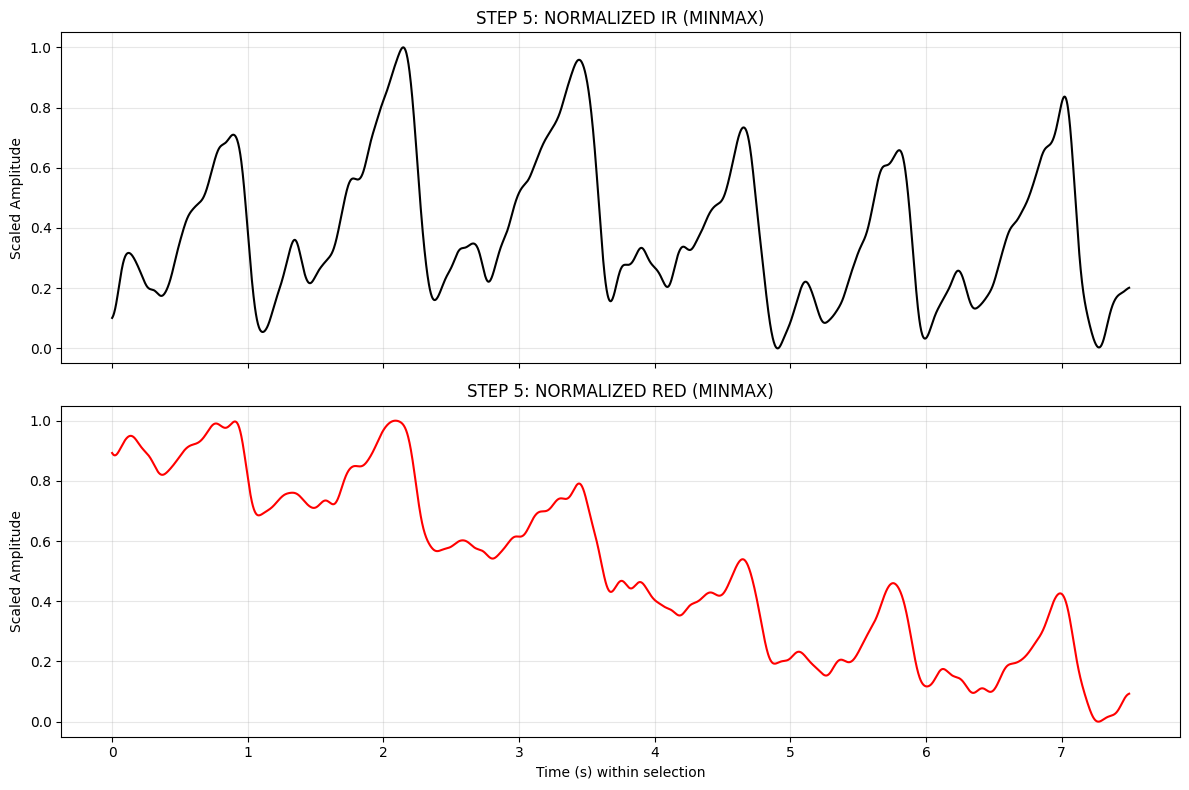

📊 Stats (MINMAX):
   RED Mean: 0.5144 | Std: 0.2870
   IR  Mean: 0.3869 | Std: 0.2383


In [5]:
# ==========================================
# ⚙️ STEP 5: NORMALIZATION (Applied AFTER Filtering)
# ==========================================
# 1. Apply Normalization to FILTERED data
red_norm = apply_normalization(red_filtered, method=NORM_METHOD)
ir_norm  = apply_normalization(ir_filtered, method=NORM_METHOD)

# 2. Plot Results (Full Selected Range)
# We use the same 't_select' from the previous block
t_select = np.arange(len(red_norm)) / FS

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# IR Channel
ax1.plot(t_select, ir_norm, color='black', linewidth=1.5)
ax1.set_title(f'STEP 5: NORMALIZED IR ({NORM_METHOD})')
ax1.set_ylabel('Scaled Amplitude')
ax1.grid(True, alpha=0.3)

# RED Channel
ax2.plot(t_select, red_norm, color='red', linewidth=1.5)
ax2.set_title(f'STEP 5: NORMALIZED RED ({NORM_METHOD})')
ax2.set_ylabel('Scaled Amplitude')
ax2.set_xlabel('Time (s) within selection')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 3. Print Stats
print(f"📊 Stats ({NORM_METHOD}):")
print(f"   RED Mean: {np.mean(red_norm):.4f} | Std: {np.std(red_norm):.4f}")
print(f"   IR  Mean: {np.mean(ir_norm):.4f} | Std: {np.std(ir_norm):.4f}")

In [6]:
# ==========================================
# ⚙️ STEP 6: ADVANCED SIGNAL QUALITY CHECK (High Standard)
# ==========================================
def calculate_snr(signal_data, fs):
    """
    Calculates Spectral Signal-to-Noise Ratio (SNR).
    Signal Power: 0.5 Hz to 5.0 Hz (Heartbeat range)
    Noise Power: Everything else.
    """
    freqs, psd = signal.periodogram(signal_data, fs)
    sig_mask = (freqs >= 0.5) & (freqs <= 5.0)
    noise_mask = ~sig_mask 
    sig_power = np.sum(psd[sig_mask])
    noise_power = np.sum(psd[noise_mask])
    if noise_power == 0: return 100.0
    return 10 * np.log10(sig_power / noise_power)

def calculate_zcr(signal_data):
    """ Measures how 'jittery' the signal is. """
    centered = signal_data - np.mean(signal_data)
    crossings = np.diff(np.signbit(centered)).sum()
    return crossings / len(signal_data)

def check_quality_advanced(name, clean_sig, raw_sig_for_dc, fs):
    print(f"\n📋 HIGH-STANDARD QUALITY REPORT: {name}")
    print("=" * 95)
    
    # --- 1. SKEWNESS (Shape Symmetry) ---
    # Healthy PPG has sharp systolic peaks => Positive Skewness (> 0.2)
    skew = stats.skew(clean_sig)
    skew_target = "> 0.2000"
    skew_status = "✅ PASS" if skew > 0.2 else "❌ FAIL (Too Flat/Inverted)"
    
    # --- 2. KURTOSIS (Peak Sharpness) ---
    # Healthy PPG is "peaky" => Positive Kurtosis (> 0.0)
    kurt = stats.kurtosis(clean_sig)
    kurt_target = "> 0.0000"
    kurt_status = "✅ PASS" if kurt > 0.0 else "⚠️ WARNING (Platykurtic)"
    
    # --- 3. PERFUSION INDEX (Signal Strength) ---
    # PI = (AC / DC) * 100
    ac_amp = np.max(clean_sig) - np.min(clean_sig)
    dc_amp = np.mean(raw_sig_for_dc)
    pi = (ac_amp / dc_amp) * 100 if dc_amp != 0 else 0
    pi_target = "> 0.1000 %"
    pi_status = "✅ PASS" if pi > 0.1 else "❌ FAIL (Too Weak)"

    # --- 4. SIGNAL-TO-NOISE RATIO (SNR) ---
    # Good clinical PPG should be > 5 dB
    snr = calculate_snr(clean_sig, fs)
    snr_target = "> 5.0000 dB"
    snr_status = "✅ PASS" if snr > 5.0 else "❌ FAIL (Too Noisy)"

    # --- 5. ZERO-CROSSING RATE (Stability) ---
    # If ZCR is too high (> 0.05), it means the signal is just static noise
    zcr = calculate_zcr(clean_sig)
    zcr_target = "< 0.0500"
    zcr_status = "✅ PASS" if zcr < 0.05 else "⚠️ WARNING (Jittery)"

    # --- PRINT TABLE ---
    # Format: Metric | Value | Target | Status
    print(f"{'METRIC':<20} | {'VALUE':<12} | {'TARGET RANGE':<15} | {'STATUS':<25}")
    print("-" * 95)
    print(f"{'Skewness':<20} | {skew:<12.4f} | {skew_target:<15} | {skew_status}")
    print(f"{'Kurtosis':<20} | {kurt:<12.4f} | {kurt_target:<15} | {kurt_status}")
    print(f"{'Perfusion Index':<20} | {pi:<12.4f} | {pi_target:<15} | {pi_status}")
    print(f"{'SNR (dB)':<20} | {snr:<12.4f} | {snr_target:<15} | {snr_status}")
    print(f"{'Zero-Crossing':<20} | {zcr:<12.4f} | {zcr_target:<15} | {zcr_status}")
    print("=" * 95)

    # Global Verdict
    if "❌" in (skew_status + pi_status + snr_status):
        print(f"🚨 FINAL VERDICT: REJECTED (Bad Signal)")
    else:
        print(f"🎉 FINAL VERDICT: ACCEPTED (Ready for AI)")

# Run Checks using 'red_filtered' (Clean AC) and 'selected_df' (Raw DC)
check_quality_advanced("RED CHANNEL", red_filtered, selected_df['RED'].values, FS)
check_quality_advanced("IR CHANNEL ", ir_filtered, selected_df['IR'].values, FS)


📋 HIGH-STANDARD QUALITY REPORT: RED CHANNEL
METRIC               | VALUE        | TARGET RANGE    | STATUS                   
-----------------------------------------------------------------------------------------------
Skewness             | 0.0338       | > 0.2000        | ❌ FAIL (Too Flat/Inverted)
Kurtosis             | -1.2154      | > 0.0000        | ⚠️ WARNING (Platykurtic)
Perfusion Index      | 0.2239       | > 0.1000 %      | ✅ PASS
SNR (dB)             | -4.6035      | > 5.0000 dB     | ❌ FAIL (Too Noisy)
Zero-Crossing        | 0.0010       | < 0.0500        | ✅ PASS
🚨 FINAL VERDICT: REJECTED (Bad Signal)

📋 HIGH-STANDARD QUALITY REPORT: IR CHANNEL 
METRIC               | VALUE        | TARGET RANGE    | STATUS                   
-----------------------------------------------------------------------------------------------
Skewness             | 0.6252       | > 0.2000        | ✅ PASS
Kurtosis             | -0.4836      | > 0.0000        | ⚠️ WARNING (Platykurtic)
Perfus